In [34]:
import pandas as pd
from preprocessing import *
import matplotlib.pyplot as plt
%matplotlib inline



In [43]:
history = pd.read_pickle("../result/history.pickle")


In [44]:
history.keys()

dict_keys(['prediction', 'acc', 'loss'])

In [45]:
predictions = np.array(history['prediction'])
predictions = predictions.reshape(predictions.shape[0])
predictions = pd.DataFrame(predictions)

test_labels = data["test_labels"].ix[:,0]
test_names  = data['test_names'].ix[:,0]
test_dates = data['test_dates'].ix[:,0]

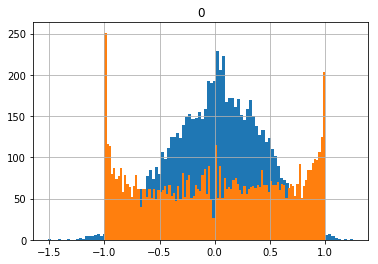

In [46]:
predictions.hist(bins=100)
test_labels.hist(bins=100)

In [47]:
result_df = pd.DataFrame()
result_df['name'] = test_names
result_df['date'] = test_dates
result_df['label'] = test_labels
result_df['prediction'] = predictions

In [48]:
result_df.head()

,name,date,label,prediction
0,spy,2015-03-24,-0.898692,-0.236648
1,spy,2015-03-25,-0.233740,-0.846313
2,spy,2015-03-26,0.225048,-0.229367
3,spy,2015-03-27,0.839650,0.356417
4,spy,2015-03-30,-0.703375,0.868107


In [49]:
result_df['disc_label'] = result_df.label.apply(lambda x: int((x+1)*(1.5)))
result_df['disc_pred'] = result_df.prediction.apply(lambda x: int((x+1)*(1.5)))

In [50]:
result_df.head()

,name,date,label,prediction,disc_label,disc_pred
0,spy,2015-03-24,-0.898692,-0.236648,0,1
1,spy,2015-03-25,-0.233740,-0.846313,1,0
2,spy,2015-03-26,0.225048,-0.229367,1,1
3,spy,2015-03-27,0.839650,0.356417,2,2
4,spy,2015-03-30,-0.703375,0.868107,0,2


In [51]:
real_buy = result_df[result_df.disc_label == 2]
real_sell = result_df[result_df.disc_label == 0]

total_buy_sgn_count = real_buy.count()
true_buy_sgn_count = np.array([real_buy.disc_pred >= 2]).sum() #1307
wrong_buy_sgn_count = np.array([real_buy.disc_pred == 0]).sum()  #37 / 2564

true_sell_sgn_count = np.array([real_sell.disc_pred == 0]).sum() #1241
wrong_sell_sgn_count = np.array([real_sell.disc_pred >= 2]).sum() #55 / 2389

In [58]:
(real_buy.name.count(), true_buy_sgn_count,wrong_buy_sgn_count),(real_sell.name.count(),true_sell_sgn_count,wrong_sell_sgn_count)

((2564, 1267, 49), (2389, 1188, 62))